In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from sklearn.decomposition import PCA

CFG = dict(
    data_root  = '/kaggle/input/datasets/crawford/emnist/',       
    split      = 'balanced',          
    batch_size = 128,
    epochs     = 30,
    lr         = 1e-3,
    val_frac   = 0.1,
    seed       = 0,
    device     = 'cuda' if torch.cuda.is_available() else 'cpu',
)

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
os.makedirs(CFG['data_root'], exist_ok=True)

print(f"Device : {CFG['device']}")
print(f"GPU    : {torch.cuda.get_device_name(0) if CFG['device']=='cuda' else 'N/A'}")

Device : cuda
GPU    : Tesla T4


In [7]:
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class EMNISTCSV(Dataset):
    def __init__(self, csv_file, transform=None):
        self.data = pd.read_csv(csv_file, header=None)
        self.transform = transform
        
        self.labels = self.data.iloc[:, 0].values
        self.images = self.data.iloc[:, 1:].values.astype(np.uint8)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        
        img = self.images[idx].reshape(28, 28)
        img = np.transpose(img)

        if self.transform:
            img = self.transform(img)
        else:
            img = torch.tensor(img, dtype=torch.float32).unsqueeze(0) / 255.0

        label = int(self.labels[idx])
        return img, label

MAPPING

In [8]:
mapping = pd.read_csv(
    f"/kaggle/input/datasets/crawford/emnist/emnist-balanced-mapping.txt",
    sep=' ', header=None
)
classes = [chr(c) for c in mapping[1]]

Train : 101,520  |  Val : 11,280  |  Test : 18,800
Classes : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'] ...


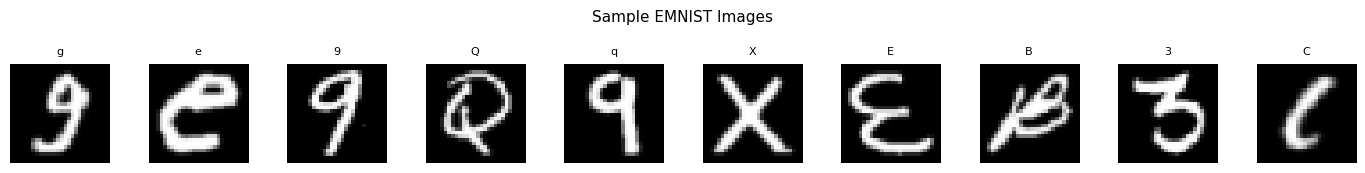

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),  
])

train_dataset = EMNISTCSV(
    f"{CFG['data_root']}/emnist-{CFG['split']}-train.csv",
    transform=transform
)
train_dataset.classes = classes
test_dataset = EMNISTCSV(
    f"{CFG['data_root']}/emnist-{CFG['split']}-test.csv",
    transform=transform
)

val_size   = int(len(train_dataset) * CFG['val_frac'])
train_size = len(train_dataset) - val_size
train_ds, val_ds = random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(CFG['seed'])
)

nw = 2 if CFG['device'] == 'cuda' else 0
train_loader = DataLoader(train_ds,    batch_size=CFG['batch_size'], shuffle=True,  num_workers=nw, pin_memory=True)
val_loader   = DataLoader(val_ds,      batch_size=CFG['batch_size'], shuffle=False, num_workers=nw, pin_memory=True)
test_loader  = DataLoader(test_dataset,batch_size=CFG['batch_size'], shuffle=False, num_workers=nw, pin_memory=True)

print(f"Train : {len(train_ds):,}  |  Val : {len(val_ds):,}  |  Test : {len(test_dataset):,}")
print(f"Classes : {train_dataset.classes[:10]} ...")

fig, axes = plt.subplots(1, 10, figsize=(14, 1.6))
imgs, lbls = next(iter(test_loader))
for i, ax in enumerate(axes):
    ax.imshow(imgs[i].squeeze().numpy(), cmap='gray')
    ax.set_title(train_dataset.classes[lbls[i]], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample EMNIST Images', fontsize=11, y=1.05)
plt.tight_layout()
plt.show()

In [36]:
class ANN_AE_Shallow(nn.Module):
    """
    ANN Design 1 — Shallow & Wide
    Encoder : 784 → 512 → 256 → [64]
    Decoder : [64] → 256 → 512 → 784
    """
    def __init__(self, bottleneck=64):
        super().__init__()
        self.bottleneck = bottleneck
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 512),        nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 784),        nn.Sigmoid(),
        )

    def forward(self, x):
        z   = self.encoder(x)
        out = self.decoder(z).view(-1, 1, 28, 28)
        return out, z


class ANN_AE_Deep(nn.Module):
    """
    ANN Design 2 — Deep & Narrow
    Encoder : 784 → 512 → 256 → 128 → 64 → [32]
    Decoder : [32] → 64 → 128 → 256 → 512 → 784
    """
    def __init__(self, bottleneck=32):
        super().__init__()
        self.bottleneck = bottleneck
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64,  bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck, 64),  nn.ReLU(),
            nn.Linear(64,  128),        nn.ReLU(),
            nn.Linear(128, 256),        nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 512),        nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 784),        nn.Sigmoid(),
        )

    def forward(self, x):
        z   = self.encoder(x)
        out = self.decoder(z).view(-1, 1, 28, 28)
        return out, z




class CNN_AE_Light(nn.Module):
    """
    CNN Design 1 — Light (fewer filters)
    Encoder : Conv(1→16,s=2) → Conv(16→32,s=2) → Flatten → Linear[128]
    Decoder : Linear[128] → ConvT(32→16,s=2) → ConvT(16→1,s=2)
    Spatial  : 28 → 14 → 7
    """
    def __init__(self, bottleneck=128):
        super().__init__()
        self.bottleneck = bottleneck
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1,  16, kernel_size=3, stride=2, padding=1),   #input size # 28→14
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),   # 14→7
            nn.BatchNorm2d(32), nn.ReLU(),
        )
        self.encoder_fc = nn.Linear(32 * 7 * 7, bottleneck)

        self.decoder_fc = nn.Linear(bottleneck, 32 * 7 * 7)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),  # 7→14
            nn.BatchNorm2d(16), nn.ReLU(),
            nn.ConvTranspose2d(16,  1, kernel_size=4, stride=2, padding=1),  # 14→28
            nn.Sigmoid(),
        )

    def forward(self, x):
        h = self.encoder_conv(x)            # (B,32,7,7)
        z = self.encoder_fc(h.flatten(1))   # (B, bottleneck)
        h2  = self.decoder_fc(z).view(-1, 32, 7, 7)
        out = self.decoder_conv(h2)         # (B,1,28,28)
        return out, z


class CNN_AE_Deep(nn.Module):
    """
    CNN Design 2 — Deep (more filters, 3 conv stages)
    Encoder : Conv(1→32,s=2) → Conv(32→64,s=2) → Conv(64→128) → Flatten → Linear[64]
    Decoder : Linear[64] → ConvT(128→64) → ConvT(64→32,s=2) → ConvT(32→1,s=2)
    Spatial  : 28 → 14 → 7 → 7
    """
    def __init__(self, bottleneck=128):
        super().__init__()
        self.bottleneck = bottleneck
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1,   32,  kernel_size=3, stride=2, padding=1),  # 28→14
            nn.BatchNorm2d(32),  nn.LeakyReLU(0.2),
            nn.Conv2d(32,  64,  kernel_size=3, stride=2, padding=1),  # 14→7
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2),
            nn.Conv2d(64,  128, kernel_size=3, stride=1, padding=1),  # 7→7
            nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
        )
        self.encoder_fc = nn.Linear(128 * 7 * 7, bottleneck)

        self.decoder_fc = nn.Linear(bottleneck, 128 * 7 * 7)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1),  # 7→7
            nn.BatchNorm2d(64),  nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(64,  32, kernel_size=4, stride=2, padding=1),  # 7→14
            nn.BatchNorm2d(32),  nn.LeakyReLU(0.2),
            nn.ConvTranspose2d(32,   1, kernel_size=4, stride=2, padding=1),  # 14→28
            nn.Sigmoid(),
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        z = self.encoder_fc(h.flatten(1))
        h2  = self.decoder_fc(z).view(-1, 128, 7, 7)
        out = self.decoder_conv(h2)
        return out, z

def count_params(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

for name, cls, kw in [
    ('ANN Shallow', ANN_AE_Shallow, dict(bottleneck=64)),
    ('ANN Deep',    ANN_AE_Deep,    dict(bottleneck=32)),
    ('CNN Light',   CNN_AE_Light,   dict(bottleneck=128)),
    ('CNN Deep',    CNN_AE_Deep,    dict(bottleneck=128)),
]:
    m = cls(**kw)
    print(f"{name:<15} | bottleneck={kw['bottleneck']:>3} | params={count_params(m):>9,}")

ANN Shallow     | bottleneck= 64 | params=1,103,184
ANN Deep        | bottleneck= 32 | params=1,153,712
CNN Light       | bottleneck=128 | params=  416,497
CNN Deep        | bottleneck= 64 | params=1,009,569


In [37]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    for imgs, _ in loader:
        imgs = imgs.to(device)
        recon, _ = model(imgs)
        loss = criterion(recon, imgs)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total += loss.item() * imgs.size(0)
    return total / len(loader.dataset)


@torch.no_grad()  
def evaluate(model, loader, criterion, device):
    model.eval()
    total = 0.0
    for imgs, _ in loader:
        imgs = imgs.to(device)
        recon, _ = model(imgs)
        total += criterion(recon, imgs).item() * imgs.size(0)
    return total / len(loader.dataset)


def train_model(model, name, epochs=CFG['epochs'], lr=CFG['lr']):
    device = CFG['device']
    model  = model.to(device)
    crit   = nn.MSELoss()
    opt    = optim.Adam(model.parameters(), lr=lr)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    hist = {'train': [], 'val': []}
    best_val, best_state = float('inf'), None

    print(f"\n{'━'*55}")
    print(f"  {name}  |  params={count_params(model):,}  |  bottleneck={model.bottleneck}")
    print(f"{'━'*55}")
    print(f"  {'Epoch':>5}  {'Train MSE':>11}  {'Val MSE':>11}")

    for ep in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, opt, crit, device)
        va = evaluate(model, val_loader, crit, device)
        sched.step()
        hist['train'].append(tr)
        hist['val'].append(va)

        if va < best_val:
            best_val   = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if ep % 5 == 0 or ep == 1:
            print(f"  {ep:>5}  {tr:>11.6f}  {va:>11.6f}")

    model.load_state_dict(best_state)
    print(f" Best val MSE : {best_val:.6f}")
    return model, hist

print('Training utilities ready')

Training utilities ready


In [46]:
MODELS_CFG = [
    ('ANN_Shallow', ANN_AE_Shallow(bottleneck=64)),
    ('ANN_Deep',    ANN_AE_Deep(bottleneck=32)),
    ('CNN_Light',   CNN_AE_Light(bottleneck=128)),
    ('CNN_Deep',    CNN_AE_Deep(bottleneck=128)),
]

trained_models = {}
histories      = {}

for name, model in MODELS_CFG:
    print("Loop start")
    model, hist = train_model(model, name)
    trained_models[name] = model
    histories[name]      = hist

Loop start

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ANN_Shallow  |  params=1,103,184  |  bottleneck=64
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch    Train MSE      Val MSE
      1     0.018437     0.009822
      5     0.006237     0.005678
     10     0.004926     0.004740
     15     0.004279     0.004045
     20     0.003855     0.003710
     25     0.003611     0.003472
     30     0.003520     0.003433
 Best val MSE : 0.003428
Loop start

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ANN_Deep  |  params=1,153,712  |  bottleneck=32
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Epoch    Train MSE      Val MSE
      1     0.066754     0.049825
      5     0.029347     0.025207
     10     0.024549     0.020937
     15     0.022645     0.018827
     20     0.021250     0.017541
     25     0.020340     0.016610
     30     0.020058     0.016356
 Best val MSE : 0.016356
Loop start

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [47]:
crit = nn.MSELoss()
print(f"\n{'Model':<15} {'Bottleneck':>12} {'Test MSE':>12} {'Compression':>14}")
print('─' * 56)
for name, model in trained_models.items():
    test_loss = evaluate(model, test_loader, crit, CFG['device'])
    ratio = 784 / model.bottleneck
    print(f"{name:<15} {model.bottleneck:>12} {test_loss:>12.6f} {ratio:>13.1f}×")


Model             Bottleneck     Test MSE    Compression
────────────────────────────────────────────────────────
ANN_Shallow               64     0.003413          12.2×
ANN_Deep                  32     0.016419          24.5×
CNN_Light                128     0.000862           6.1×
CNN_Deep                 128     0.000566           6.1×


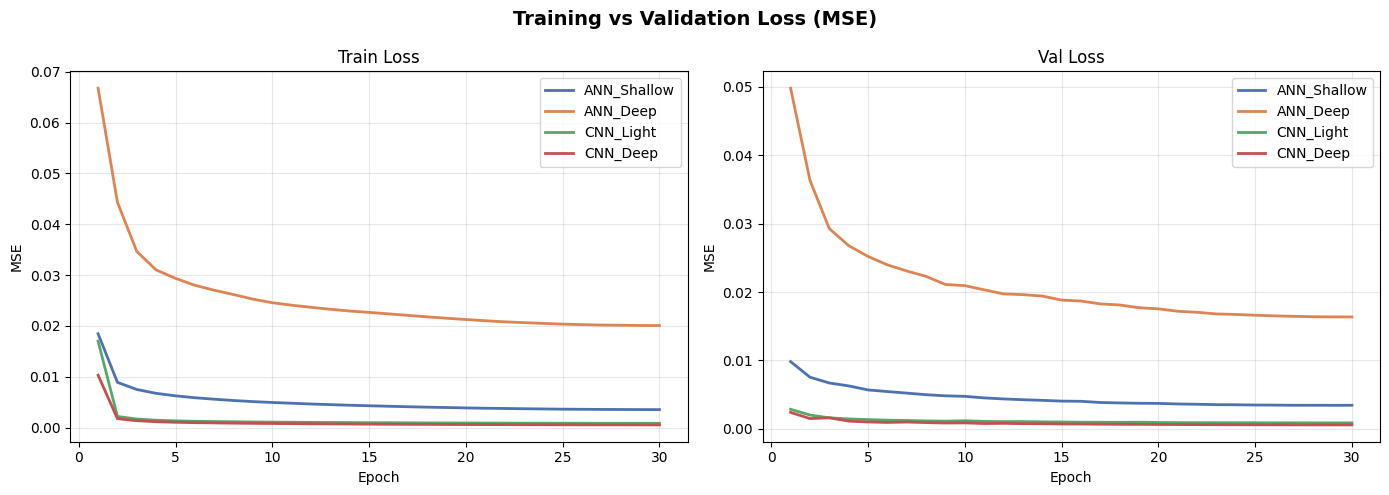

In [48]:
COLORS = {
    'ANN_Shallow': '#4C72B0',
    'ANN_Deep'   : '#DD8452',
    'CNN_Light'  : '#55A868',
    'CNN_Deep'   : '#C44E52',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training vs Validation Loss (MSE)', fontsize=14, fontweight='bold')

for ax, split in zip(axes, ['train', 'val']):
    for name, hist in histories.items():
        ax.plot(range(1, len(hist[split]) + 1), hist[split],
                label=name, color=COLORS[name], linewidth=2)
    ax.set_title(f'{split.capitalize()} Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

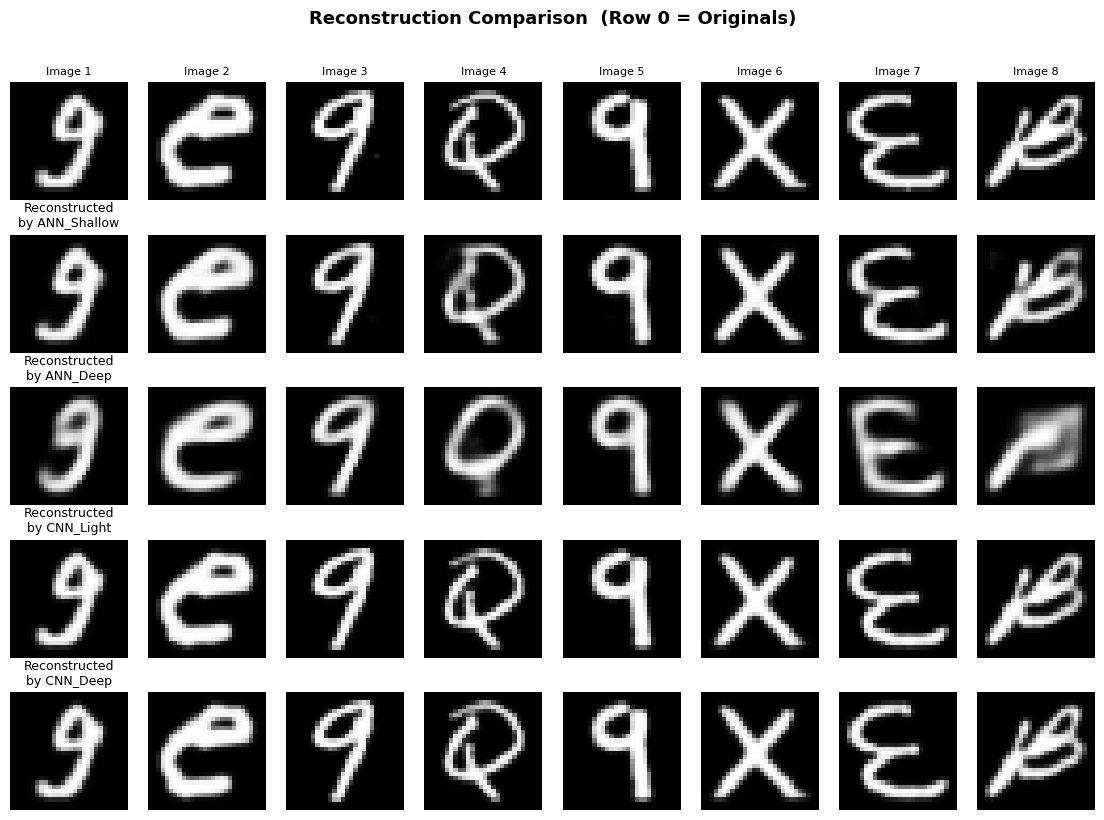

In [49]:
device = CFG['device']
N = 8  

imgs, lbls = next(iter(test_loader))
imgs = imgs[:N].to(device)

n_rows = len(trained_models) + 1
fig, axes = plt.subplots(n_rows, N, figsize=(N * 1.4, n_rows * 1.6))
fig.suptitle('Reconstruction Comparison  (Row 0 = Originals)', fontsize=13, fontweight='bold', y=1.02)

# Row 0 : originals
for j in range(N):
    axes[0, j].imshow(imgs[j].cpu().squeeze().numpy(), cmap='gray')
    axes[0, j].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=9, rotation=0, labelpad=50)

# Rows 1-4 : reconstructions
for i, (name, model) in enumerate(trained_models.items(), start=1):
    model.eval()
    with torch.no_grad():  #disables gradient computation as we are only visualizing speeding up computation
        recon, _ = model(imgs)
    for j in range(N):
        axes[i, j].imshow(recon[j].cpu().squeeze().numpy(), cmap='gray')
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(name, fontsize=8, rotation=0, labelpad=55)
    axes[i, 0].set_title(f'Reconstructed\nby {name}', fontsize=9)
for j in range(N):
    axes[0, j].set_title(f'Image {j+1}', fontsize=8)
plt.tight_layout()
plt.show()

Latent Space Visualisation

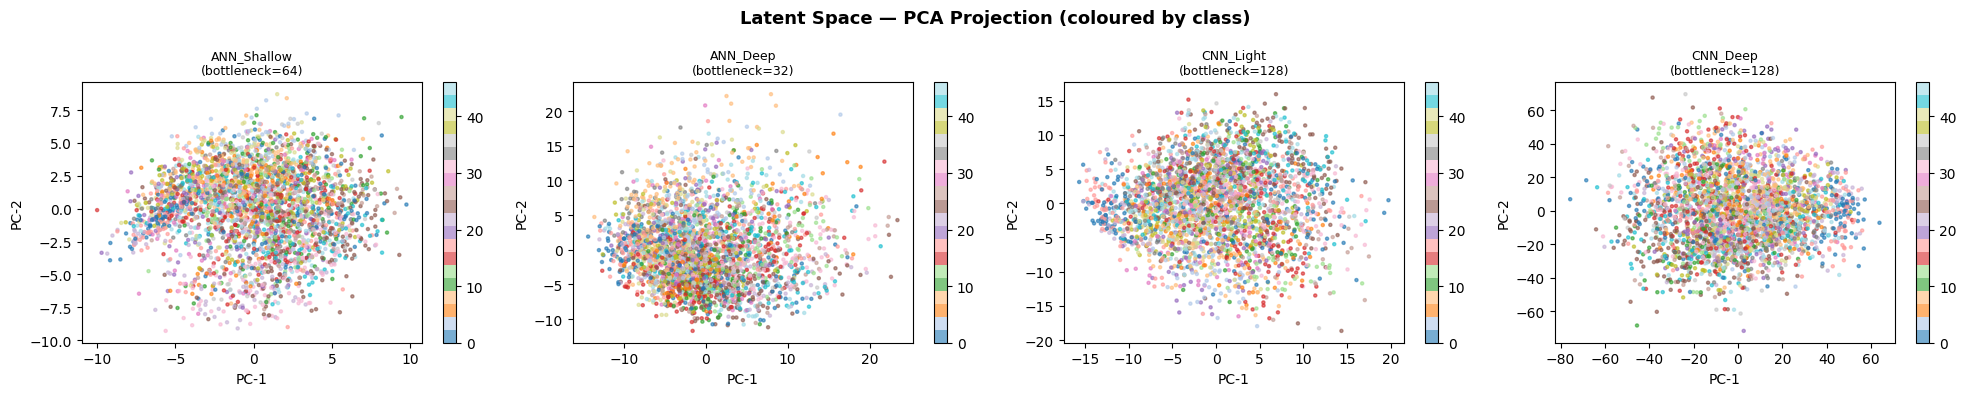

In [50]:
MAX_SAMPLES = 3000

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Latent Space — PCA Projection (coloured by class)', fontsize=13, fontweight='bold')

for ax, (name, model) in zip(axes, trained_models.items()):
    model.eval()
    all_z, all_l = [], []
    with torch.no_grad():
        for xb, lb in test_loader:
            _, z = model(xb.to(device))
            all_z.append(z.cpu().numpy())
            all_l.append(lb.numpy())
            if sum(len(a) for a in all_z) >= MAX_SAMPLES:
                break

    Z = np.concatenate(all_z)[:MAX_SAMPLES]
    L = np.concatenate(all_l)[:MAX_SAMPLES]

    Z2 = PCA(n_components=2, random_state=42).fit_transform(Z) if Z.shape[1] > 2 else Z

    sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=L, cmap='tab20', s=5, alpha=0.6)
    ax.set_title(f'{name}\n(bottleneck={model.bottleneck})', fontsize=9)
    ax.set_xlabel('PC-1'); ax.set_ylabel('PC-2')
    plt.colorbar(sc, ax=ax)

plt.tight_layout()
plt.show()

Model Comparison


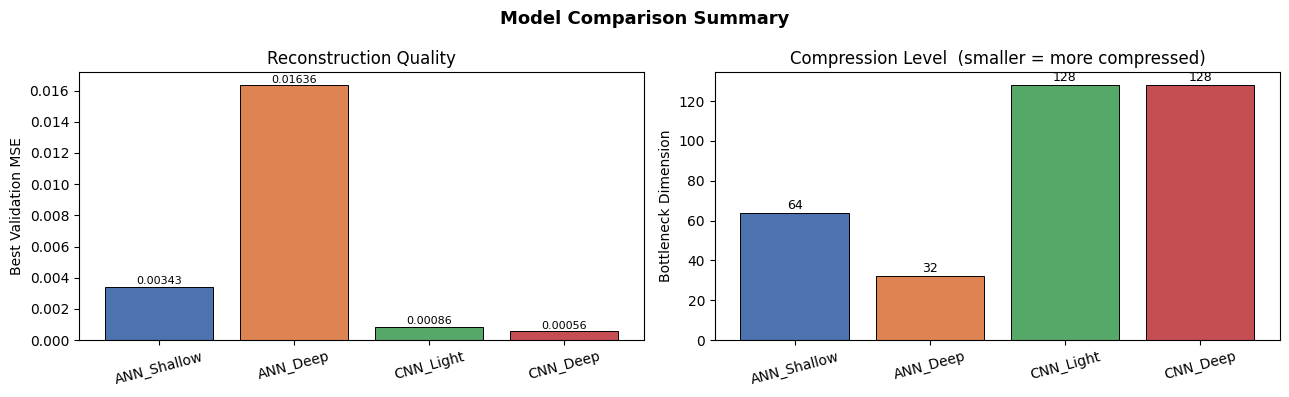

In [51]:
names      = list(histories.keys())
best_vals  = [min(histories[n]['val']) for n in names]
bottlenecks = [trained_models[n].bottleneck for n in names]
colors     = [COLORS[n] for n in names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Model Comparison Summary', fontsize=13, fontweight='bold')


bars = ax1.bar(names, best_vals, color=colors, edgecolor='k', linewidth=0.7)
ax1.set_ylabel('Best Validation MSE')
ax1.set_title('Reconstruction Quality')
for bar, val in zip(bars, best_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3e-5,
             f'{val:.5f}', ha='center', va='bottom', fontsize=8)
ax1.tick_params(axis='x', rotation=15)


bars2 = ax2.bar(names, bottlenecks, color=colors, edgecolor='k', linewidth=0.7)
ax2.set_ylabel('Bottleneck Dimension')
ax2.set_title('Compression Level  (smaller = more compressed)')
for bar, val in zip(bars2, bottlenecks):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=9)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Latent Space Interpolation (CNN-Deep)

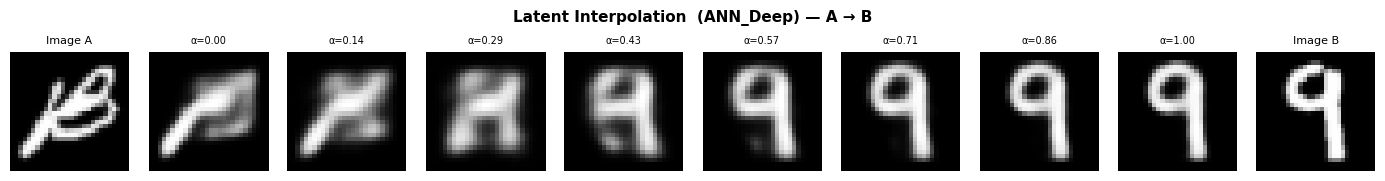

In [58]:
def interpolate(model, img_a, img_b, steps=8, device=CFG['device']):
    """Linearly interpolate between two images in latent space."""
    model.eval()
    with torch.no_grad():
        _, z1 = model(img_a.to(device))
        _, z2 = model(img_b.to(device))

    frames = []
    for a in np.linspace(0, 1, steps):
        z = (1 - a) * z1 + a * z2
        with torch.no_grad():
            if hasattr(model, 'decoder_fc'):   # CNN
                h   = model.decoder_fc(z).view(-1, model.decoder_conv[0].in_channels, 7, 7)
                out = model.decoder_conv(h)
            else:                              # ANN
                out = model.decoder(z).view(-1, 1, 28, 28)
        frames.append(out.cpu().squeeze().numpy())
    return frames

imgs, lbls = next(iter(test_loader))
x1, x2 = imgs[7:8], imgs[4:5]   # pick two different characters
model_name='ANN_Deep'
model  = trained_models[model_name]
frames = interpolate(model, x1, x2, steps=8)

total = len(frames) + 2
fig, axes = plt.subplots(1, total, figsize=(total * 1.4, 1.8))
fig.suptitle(f'Latent Interpolation  ({model_name}) — A → B', fontsize=11, fontweight='bold')

axes[0].imshow(x1.squeeze().numpy(), cmap='gray')
axes[0].set_title('Image A', fontsize=8)

for i, frame in enumerate(frames, 1):
    a_val = (i - 1) / (len(frames) - 1)
    axes[i].imshow(frame, cmap='gray')
    axes[i].set_title(f'α={a_val:.2f}', fontsize=7)

axes[-1].imshow(x2.squeeze().numpy(), cmap='gray')
axes[-1].set_title('Image B', fontsize=8)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

Filter Visualisation (CNN Encoder Weights)

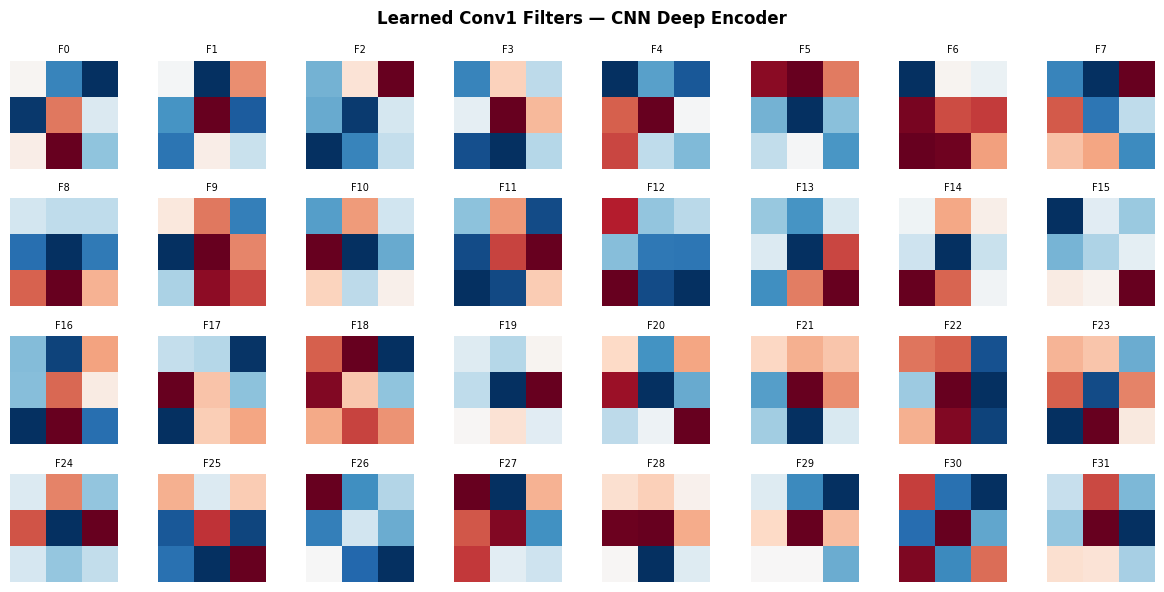

In [53]:
# Visualise the 32 learned first-layer filters of CNN-Deep
model  = trained_models['CNN_Deep']
w      = model.encoder_conv[0].weight.data.cpu()  # (32, 1, 3, 3)
n_filt = w.shape[0]

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
fig.suptitle('Learned Conv1 Filters — CNN Deep Encoder', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < n_filt:
        filt = w[i, 0].numpy()
        filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)  # normalise to [0,1]
        ax.imshow(filt, cmap='RdBu_r', vmin=0, vmax=1)
        ax.set_title(f'F{i}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()